# Autism Risk Screening — Southern Africa (Lesotho)
### Multimodal AI Pipeline

**Pipeline sections:**
1. Imports & setup
2. Data loading & preprocessing
3. Exploratory data analysis
4. Model training
5. Late fusion & evaluation
6. DHS threshold recalibration
7. SHAP explainability
8. Cultural alignment analysis
9. Subgroup fairness evaluation
10. Save models

> Research prototype — not for clinical use.

# Install dependencies

In [1]:

 !pip install xgboost shap librosa imbalanced-learn pyreadstat openpyxl seaborn --quiet


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import os, warnings
from pathlib import Path
import traceback

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split, learning_curve
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score, accuracy_score
)
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import xgboost as xgb

try:
    import shap
    SHAP_AVAILABLE = True
except Exception as exc:
    shap = None
    SHAP_AVAILABLE = False
    SHAP_IMPORT_ERROR = traceback.format_exc()
    print(f"SHAP unavailable; explainability steps will be skipped. ({exc.__class__.__name__}: {exc})")

import joblib

SEED = 42
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd()
for candidate in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
    if (candidate / "data" / "raw" / "qchat" / "Autusim_DATA_Clean_Encoded.xlsx").exists():
        PROJECT_ROOT = candidate
        break

os.chdir(PROJECT_ROOT)
os.makedirs("outputs/evaluation", exist_ok=True)
os.makedirs("outputs/fairness",   exist_ok=True)
os.makedirs("outputs/alignment",  exist_ok=True)
os.makedirs("models",             exist_ok=True)

print("Imports OK  |  XGBoost", xgb.__version__)
print(f"Project root: {PROJECT_ROOT}")

SHAP unavailable; explainability steps will be skipped.
Imports OK  |  XGBoost 2.0.3
Project root: c:\Users\PC\Autism-Risk-Screening


---
## Section 1 · Data Loading & Preprocessing

**Training data:** Unified Q-CHAT-10 toddler dataset (Abbadi & Thabtah, 2025)  
Filtered to ages 18–36 months (1.5–3.0 years) → 1,601 records

**Test data:** Polish clinical dataset (Niedźwiecka et al., 2020)  
Q-CHAT-25 format — items QCHAT1RE–QCHAT10R used  
Loaded via pyreadstat from `data/raw/qchat/QCHAT_dataset2_mendeley.sav`

In [6]:
# Load Q-CHAT dataset
df_raw = pd.read_excel("data/raw/qchat/Autusim_DATA_Clean_Encoded.xlsx")

# Keep only toddlers aged 18–36 months
df = df_raw[
    (df_raw["Age"] >= 1.5) &
    (df_raw["Age"] <= 3.0)
].copy()

# Rename columns to match the training pipeline
df = df.rename(columns={
    "a1": "q1",
    "a2": "q2",
    "a3": "q3",
    "a4": "q4",
    "a5": "q5",
    "a6": "q6",
    "a7": "q7",
    "a8": "q8",
    "a9": "q9",
    "a10": "q10",
    "Age": "age_years",
    "Gender": "sex",
    "Class": "label"
})

# Remove any age values outside the target range
df = df[df["age_years"] <= 3.0]

print(f"Training dataset: {len(df)} rows")

print(
    f"Age range: "
    f"{df['age_years'].min():.2f}–{df['age_years'].max():.2f} years "
    f"({df['age_years'].min()*12:.0f}–{df['age_years'].max()*12:.0f} months)"
)

print(f"Class distribution: {df['label'].value_counts().to_dict()}")

print(
    f"Sex distribution: {df['sex'].value_counts().to_dict()} "
    f"(0 = Female, 1 = Male)"
)

df.head()

Training dataset: 1601 rows
Age range: 1.50–3.00 years (18–36 months)
Class distribution: {0: 929, 1: 672}
Sex distribution: {1: 1154, 0: 447} (0 = Female, 1 = Male)


,id,q1,q2,q3,q4,q5,q6,q7,q8,q9,q10,age_years,sex,Ethnicity,Jaundice,Family_ASD,label,Who_Completed,Qchat_Score
0,1,0,0,0,0,0,0,1,1,0,1,2.333333,0,0,0,0,0,family member,3
1,2,1,1,0,0,0,1,1,0,0,0,3.000000,1,1,0,0,1,family member,4
2,3,1,0,0,0,0,0,1,1,0,1,3.000000,1,0,0,0,1,family member,4
3,4,1,1,1,1,1,1,1,1,1,1,2.000000,1,2,1,0,1,family member,10
4,5,1,1,0,1,1,1,1,1,1,1,1.666667,0,1,1,1,1,family member,9


In [10]:
# Load Polish clinical test set (Q-CHAT-25, items 1–10 used)

try:
    import pyreadstat

    df_test_raw, meta = pyreadstat.read_sav(
        "data/raw/qchat/QCHAT_dataset2 mendeley.sav"
    )

    def pick_column(frame, candidates):
        column_lookup = {column.lower(): column for column in frame.columns}
        for candidate in candidates:
            found = column_lookup.get(candidate.lower())
            if found is not None:
                return found
        return None

    age_col = pick_column(df_test_raw, ["AGE", "Age", "age", "AGE_MONTHS", "AgeMonths", "age_months"])
    sex_col = pick_column(df_test_raw, ["SEX", "Sex", "sex", "Gender", "gender"])
    group_col = pick_column(df_test_raw, ["GROUP", "Group", "group", "LABEL", "Label", "label", "Class", "class"])

    qchat_map = {}
    missing_items = []
    for i in range(1, 11):
        q_col = pick_column(
            df_test_raw,
            [f"QCHAT{i}RE", f"QCHAT{i}R", f"QCHAT{i}", f"qchat{i}recode", f"qchat{i}recoded", f"qchat{i}recoded"]
        )
        if q_col is None:
            missing_items.append(i)
        else:
            qchat_map[q_col] = f"q{i}"

    if age_col is None or sex_col is None or group_col is None or missing_items:
        raise KeyError(
            f"Missing columns in Polish .sav. age={age_col}, sex={sex_col}, label={group_col}, missing_q={missing_items}, available={list(df_test_raw.columns)}"
        )

    df_test = df_test_raw.rename(columns={
        age_col: "age_raw",
        sex_col: "sex",
        group_col: "label",
        **qchat_map,
    })

    # Convert age to years if the source file stores months.
    df_test["age_raw"] = pd.to_numeric(df_test["age_raw"], errors="coerce")
    df_test["age_years"] = np.where(df_test["age_raw"].max() > 10, df_test["age_raw"] / 12.0, df_test["age_raw"])

    # Inspect SPSS encodings when available.
    print("\nSEX labels:")
    print(meta.variable_value_labels.get(sex_col, "Not available"))

    print("\nGROUP labels:")
    print(meta.variable_value_labels.get(group_col, "Not available"))

    # Keep toddlers only (18–36 months = 1.5–3.0 years)
    df_test = df_test[
        (df_test["age_years"] >= 1.5) &
        (df_test["age_years"] <= 3.0)
    ].copy()

    # Adjust these mappings if metadata shows different encodings
    # Example: Male = 1, Female = 0
    df_test["sex"] = pd.to_numeric(df_test["sex"], errors="coerce")
    df_test["sex"] = (df_test["sex"] == 1).astype(int)

    # Example: ASD = 1, Control = 0
    df_test["label"] = pd.to_numeric(df_test["label"], errors="coerce")
    df_test["label"] = (df_test["label"] == 1).astype(int)

    # Remove incomplete records
    required_cols = (
        [f"q{i}" for i in range(1, 11)] +
        ["age_years", "sex", "label"]
    )

    df_test = df_test.dropna(subset=required_cols)

    print(f"\nPolish test set: {len(df_test)} rows")
    print(
        f"Age range: {df_test['age_years'].min():.2f}–"
        f"{df_test['age_years'].max():.2f} years"
    )
    print(f"Class dist: {df_test['label'].value_counts().to_dict()}")
    print(f"Sex dist: {df_test['sex'].value_counts().to_dict()}")

    USE_POLISH_TEST = True

except Exception as e:
    print(f"Polish .sav not loaded ({e})")
    print("Falling back to 80/20 split of unified dataset.")
    USE_POLISH_TEST = False


SEX labels:
{1.0: 'Male', 2.0: 'Female'}

GROUP labels:
{1.0: 'ASD', 7.0: 'control'}

Polish test set: 252 rows
Age range: 1.50–2.00 years
Class dist: {1: 135, 0: 117}
Sex dist: {1: 157, 0: 95}


In [11]:
QCHAT_COLS = [f"q{i}" for i in range(1, 11)]

if USE_POLISH_TEST:

    # External validation using Polish clinical dataset
    X_beh_train = df[QCHAT_COLS].values.astype(float)
    X_dem_train = df[["age_years", "sex"]].values.astype(float)
    y_train     = df["label"].values.astype(int)

    X_beh_test  = df_test[QCHAT_COLS].values.astype(float)
    X_dem_test  = df_test[["age_years", "sex"]].values.astype(float)
    y_test      = df_test["label"].values.astype(int)

    df_test_ref = df_test.reset_index(drop=True)

else:

    # Internal validation using stratified train/test split
    X_beh_all = df[QCHAT_COLS].values.astype(float)
    X_dem_all = df[["age_years", "sex"]].values.astype(float)
    y_all     = df["label"].values.astype(int)

    X_beh_train, X_beh_test, y_train, y_test = train_test_split(
        X_beh_all,
        y_all,
        test_size=0.20,
        stratify=y_all,
        random_state=SEED,
    )

    idx_train, idx_test = train_test_split(
        np.arange(len(df)),
        test_size=0.20,
        stratify=y_all,
        random_state=SEED,
    )

    X_dem_train = X_dem_all[idx_train]
    X_dem_test  = X_dem_all[idx_test]

    df_test_ref = df.iloc[idx_test].reset_index(drop=True)

print(f"Train samples: {len(y_train)}")
print(f"Test samples:  {len(y_test)}")

print(
    f"Train class distribution: "
    f"{dict(zip(*np.unique(y_train, return_counts=True)))}"
)

print(
    f"Test class distribution:  "
    f"{dict(zip(*np.unique(y_test, return_counts=True)))}"
)

Train samples: 1601
Test samples:  252
Train class distribution: {0: 929, 1: 672}
Test class distribution:  {0: 117, 1: 135}


---
## Section 2 · Exploratory Data Analysis

Exploratory Data Analysis (EDA) was conducted to understand the characteristics of the training dataset before model development. The analysis examined the distribution of autism classifications, age, sex, and source datasets. Only the New Zealand and Saudi Arabian datasets were included in this stage, as the Polish dataset was reserved for external validation and was not used during model training.

The objective of this analysis was to identify potential class imbalance, demographic patterns, and differences in sample representation that could influence model performance. Understanding these characteristics helps ensure that the machine learning models are trained on data that are representative of the study population and provides context for interpreting the evaluation results.


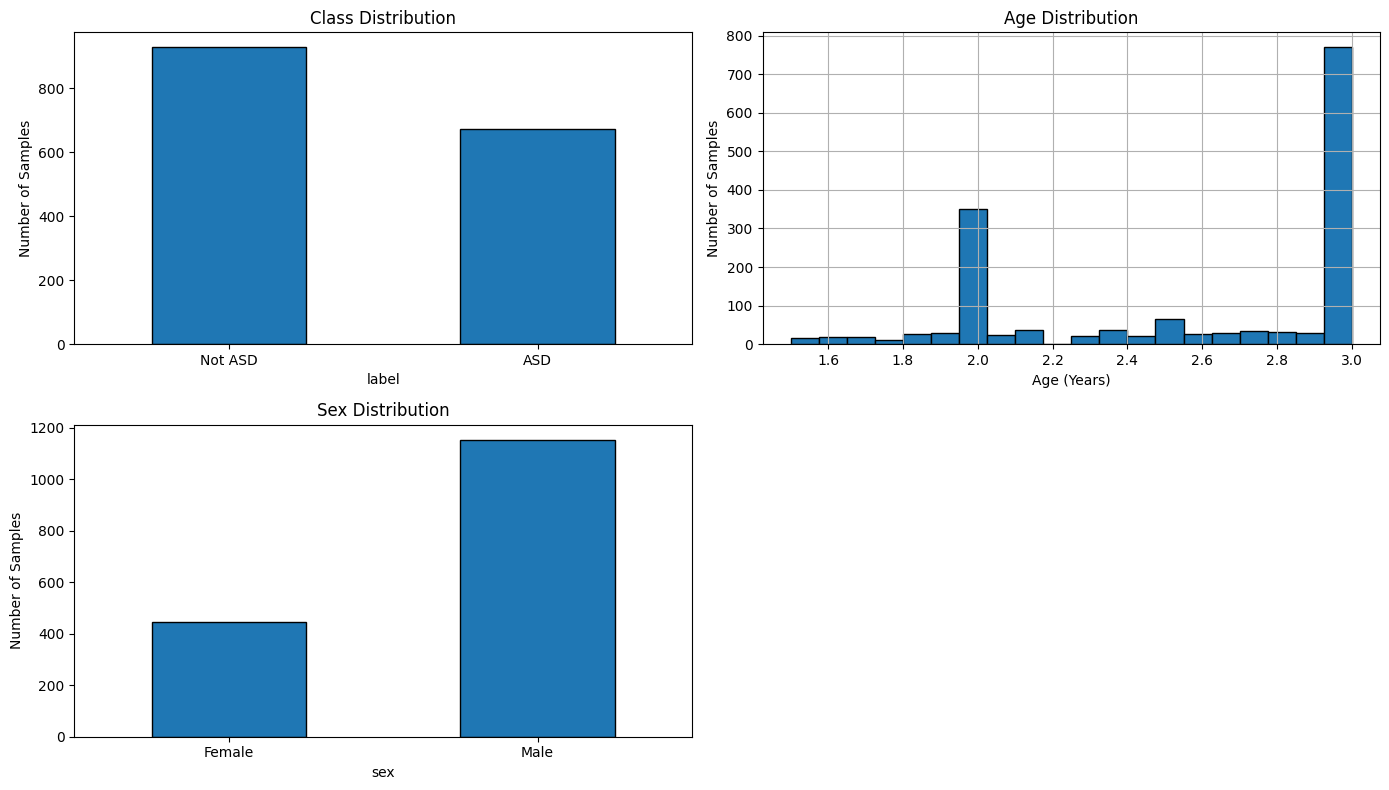


=== Training Dataset Summary ===
Samples: 1601
Class distribution: {0: 929, 1: 672}
Sex distribution: {1: 1154, 0: 447}
Age range: 1.50–3.00 years


In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Class distribution
df["label"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[0, 0],
    edgecolor="black"
)
axes[0, 0].set_xticklabels(["Not ASD", "ASD"], rotation=0)
axes[0, 0].set_title("Class Distribution")
axes[0, 0].set_ylabel("Number of Samples")

# Age distribution
df["age_years"].hist(
    bins=20,
    ax=axes[0, 1],
    edgecolor="black"
)
axes[0, 1].set_title("Age Distribution")
axes[0, 1].set_xlabel("Age (Years)")
axes[0, 1].set_ylabel("Number of Samples")

# Sex distribution
df["sex"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[1, 0],
    edgecolor="black"
)
axes[1, 0].set_xticklabels(["Female", "Male"], rotation=0)
axes[1, 0].set_title("Sex Distribution")
axes[1, 0].set_ylabel("Number of Samples")

# Training source distribution (NZ + Saudi only)
if "source" in df.columns:
    df["source"].value_counts().plot(
        kind="bar",
        ax=axes[1, 1],
        edgecolor="black"
    )
    axes[1, 1].set_title("Training Dataset Sources")
    axes[1, 1].set_xlabel("Source")
    axes[1, 1].set_ylabel("Number of Samples")
    axes[1, 1].tick_params(axis="x", rotation=0)
else:
    axes[1, 1].axis("off")

plt.tight_layout()
plt.savefig(
    "outputs/evaluation/eda_overview.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Summary statistics
print("\n=== Training Dataset Summary ===")
print(f"Samples: {len(df)}")
print(f"Class distribution: {df['label'].value_counts().to_dict()}")
print(f"Sex distribution: {df['sex'].value_counts().to_dict()}")
print(f"Age range: {df['age_years'].min():.2f}–{df['age_years'].max():.2f} years")

if "source" in df.columns:
    print(f"Source distribution: {df['source'].value_counts().to_dict()}")

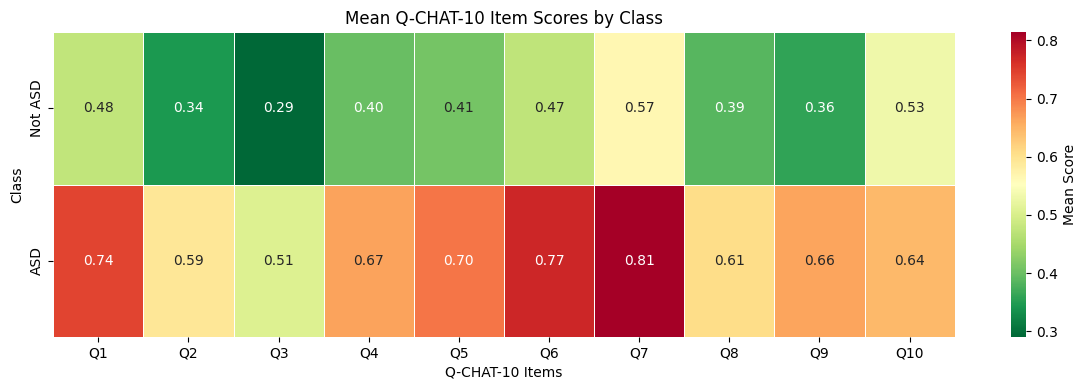

In [26]:
# Mean Q-CHAT-10 item scores by autism class
item_means = df.groupby("label")[QCHAT_COLS].mean()

fig, ax = plt.subplots(figsize=(12, 4))

sns.heatmap(
    item_means,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn_r",
    linewidths=0.5,
    cbar_kws={"label": "Mean Score"},
    xticklabels=[f"Q{i}" for i in range(1, 11)],
    yticklabels=["Not ASD", "ASD"],
    ax=ax
)

ax.set_title("Mean Q-CHAT-10 Item Scores by Class")
ax.set_xlabel("Q-CHAT-10 Items")
ax.set_ylabel("Class")

plt.tight_layout()
plt.savefig(
    "outputs/evaluation/qchat_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

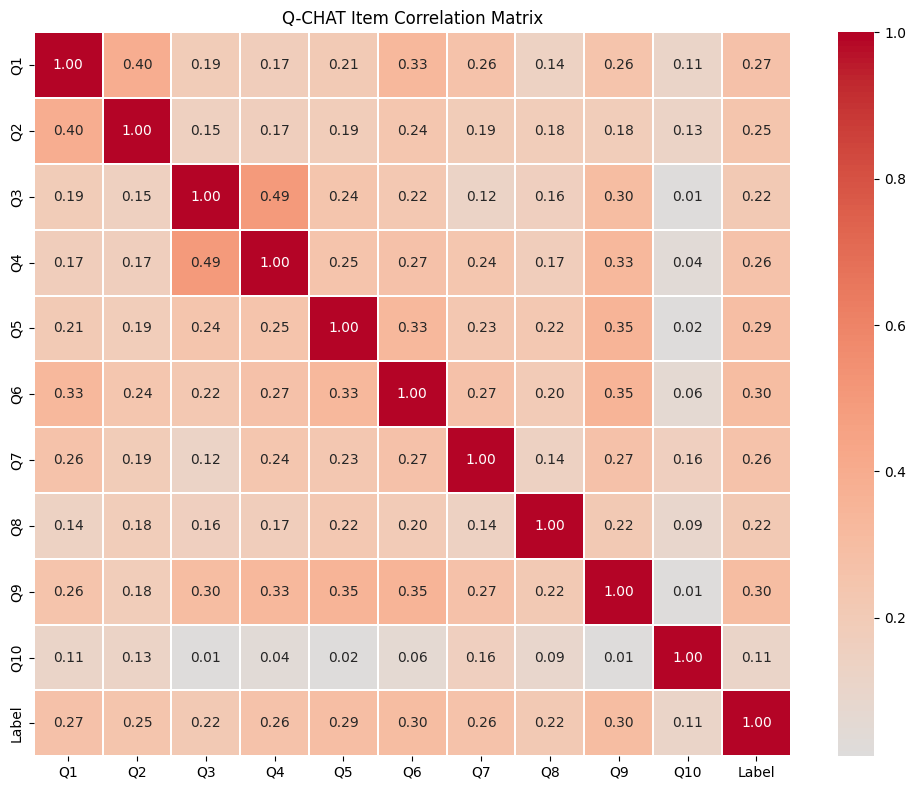

In [27]:
# Q-CHAT correlation matrix 

import matplotlib.pyplot as plt

cols = QCHAT_COLS + ["label"]

corr = df[cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=ax,
    xticklabels=[f"Q{i}" for i in range(1, 11)] + ["Label"],
    yticklabels=[f"Q{i}" for i in range(1, 11)] + ["Label"],
    linewidths=0.3
)

ax.set_title("Q-CHAT Item Correlation Matrix")
plt.tight_layout()

os.makedirs("outputs/evaluation", exist_ok=True)
plt.savefig("outputs/evaluation/correlation_matrix.png", dpi=150)

plt.show()

---
## Section 3 · Model Training

In [28]:

# Behavioural model (clean pipeline)
xgb_beh = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=SEED,
)

pipeline_beh = Pipeline([
    ("smote", SMOTE(random_state=SEED)),
    ("model", xgb_beh)
])

# Cross-validation (SMOTE applied ONLY inside folds)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_beh = cross_val_score(
    pipeline_beh,
    X_beh_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

# Fit final model on full resampled training set
smote = SMOTE(random_state=SEED)
X_beh_train_res, y_beh_train_res = smote.fit_resample(X_beh_train, y_train)
xgb_beh.fit(X_beh_train_res, y_beh_train_res)

print(f"Behavioural XGBoost — CV AUROC: {cv_beh.mean():.3f} ± {cv_beh.std():.3f}")

Behavioural XGBoost — CV AUROC: 0.682 ± 0.017


In [29]:

# Demographic model — age + sex
xgb_dem = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=SEED,
)

smote = SMOTE(random_state=SEED)
X_dem_train_res, y_dem_train_res = smote.fit_resample(X_dem_train, y_train)

# Train final model
xgb_dem.fit(X_dem_train_res, y_dem_train_res)

# Cross-validation (correct target explicitly)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_dem = cross_val_score(
    xgb_dem,
    X_dem_train_res,
    y_dem_train_res,
    cv=cv,
    scoring="roc_auc"
)

print(f"Demographic XGBoost — CV AUROC: {cv_dem.mean():.3f} ± {cv_dem.std():.3f}")

Demographic XGBoost — CV AUROC: 0.728 ± 0.015


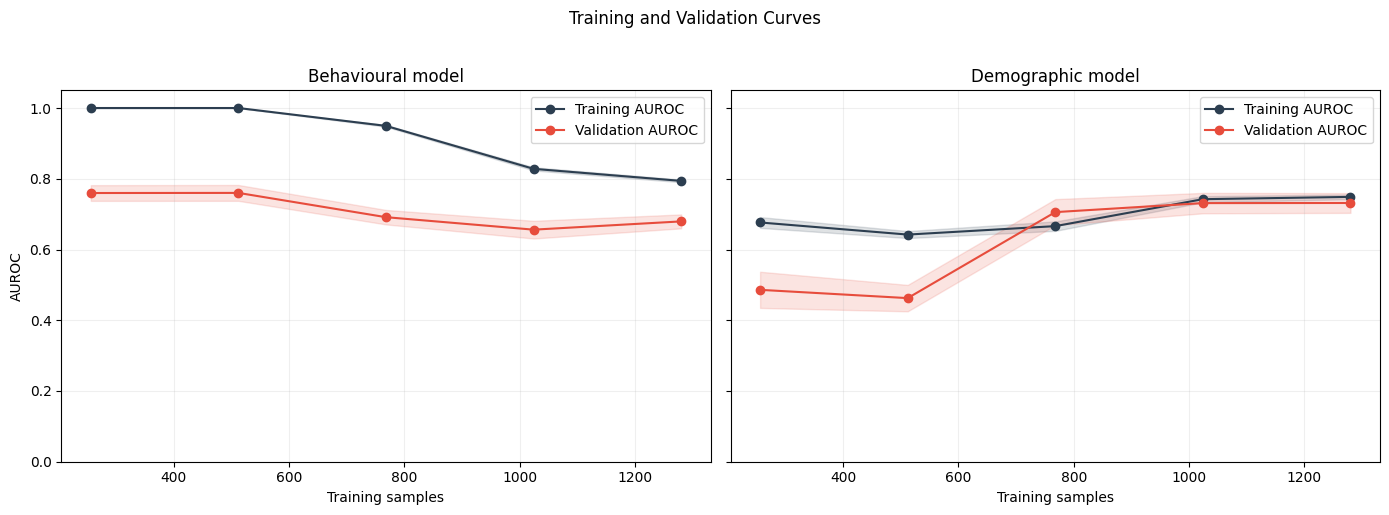

In [50]:
# Training and validation curves
learning_curves = [
    ("Behavioural model", pipeline_beh, X_beh_train, y_train, "outputs/evaluation/behavioural_learning_curve.png"),
    ("Demographic model", Pipeline([("smote", SMOTE(random_state=SEED)), ("model", xgb_dem)]), X_dem_train, y_train, "outputs/evaluation/demographic_learning_curve.png"),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (title, estimator, features, target, output_path) in zip(axes, learning_curves):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator,
        features,
        target,
        train_sizes=np.linspace(0.2, 1.0, 5),
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
        scoring="roc_auc",
        n_jobs=-1,
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, marker="o", color="#2c3e50", label="Training AUROC")
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color="#2c3e50", alpha=0.15)
    ax.plot(train_sizes, val_mean, marker="o", color="#e74c3c", label="Validation AUROC")
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, color="#e74c3c", alpha=0.15)
    ax.set_title(title)
    ax.set_xlabel("Training samples")
    ax.set_ylim(0.0, 1.05)
    ax.grid(alpha=0.2)
    ax.legend()

axes[0].set_ylabel("AUROC")
plt.suptitle("Training and Validation Curves", y=1.02)
plt.tight_layout()
plt.savefig("outputs/evaluation/training_validation_curves.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Section 4 · Late Fusion & Evaluation

In [30]:
# Base model predictions

prob_beh_train = xgb_beh.predict_proba(X_beh_train)[:, 1]
prob_dem_train = xgb_dem.predict_proba(X_dem_train)[:, 1]

prob_beh_test = xgb_beh.predict_proba(X_beh_test)[:, 1]
prob_dem_test = xgb_dem.predict_proba(X_dem_test)[:, 1]


# Meta-features (stacking input)

X_meta_train = np.column_stack([prob_beh_train, prob_dem_train])
X_meta_test  = np.column_stack([prob_beh_test, prob_dem_test])


# Train meta-model (fusion brain)

meta_model = LogisticRegression()
meta_model.fit(X_meta_train, y_train)


# Final prediction

prob_fused = meta_model.predict_proba(X_meta_test)[:, 1]
prob_fuse = prob_fused

THRESHOLD = 0.5
threshold = THRESHOLD
y_pred = (prob_fuse >= THRESHOLD).astype(int)


# Evaluation

print("=== Stacked Fusion Model (Behavioural + Demographic) ===")

print(classification_report(
    y_test,
    y_pred,
    target_names=["Not ASD", "ASD"]
))

auroc = roc_auc_score(y_test, prob_fuse)
print(f"AUROC: {auroc:.3f}")

=== Stacked Fusion Model (Behavioural + Demographic) ===
              precision    recall  f1-score   support

     Not ASD       0.68      0.26      0.37       117
         ASD       0.58      0.90      0.71       135

    accuracy                           0.60       252
   macro avg       0.63      0.58      0.54       252
weighted avg       0.63      0.60      0.55       252

AUROC: 0.710


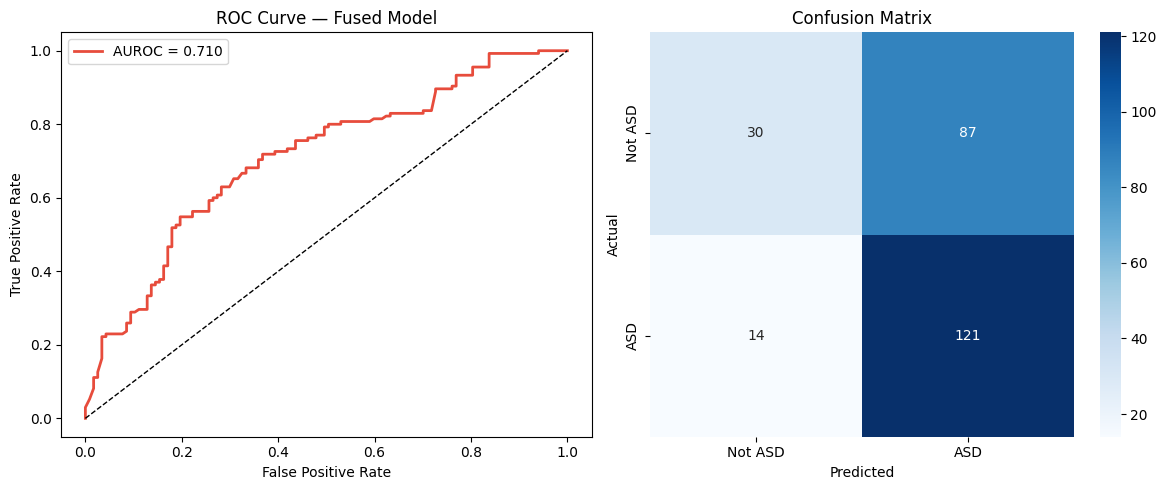

In [31]:
# ROC curve + AUROC

fpr, tpr, _ = roc_curve(y_test, prob_fused)
auroc = roc_auc_score(y_test, prob_fused)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, color="#e74c3c", lw=2, label=f"AUROC = {auroc:.3f}")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)

axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve — Fused Model")
axes[0].legend()


# Confusion matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[1],
    xticklabels=["Not ASD", "ASD"],
    yticklabels=["Not ASD", "ASD"]
)

axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title("Confusion Matrix")


# Save + show

plt.tight_layout()
plt.savefig("outputs/evaluation/roc_and_cm.png", dpi=150)
plt.show()


## Section 5 · DHS Threshold Recalibration




In [38]:
# Load DHS data

DHS_DTA_PATH = "data/raw/dhs/LSKR81FL.DTA"
DHS_CSV_PATH = "data/raw/dhs/LSKR81FL.csv"


def load_dhs_file(path):
    """Try the available Stata readers before falling back to report values."""
    try:
        import pyreadstat
        return pyreadstat.read_dta(path)
    except Exception as primary_error:
        try:
            # pandas uses a different reader path and can occasionally succeed
            # where the installed pyreadstat build cannot.
            return pd.read_stata(path)
        except Exception as secondary_error:
            raise RuntimeError(
                f"pyreadstat failed: {primary_error}; pandas.read_stata failed: {secondary_error}"
            )


try:
    if os.path.exists(DHS_CSV_PATH):
        df_dhs = pd.read_csv(DHS_CSV_PATH)
        meta = None
    else:
        df_dhs, meta = load_dhs_file(DHS_DTA_PATH)

    df = df_dhs.copy()

    # Clean variable safety layer
    df["hw70"] = pd.to_numeric(df["hw70"], errors="coerce")   # stunting (HAZ)
    df["hw57"] = pd.to_numeric(df["hw57"], errors="coerce")   # anaemia
    df["b9"]   = pd.to_numeric(df["b9"], errors="coerce")     # parental presence
    df["v025"] = pd.to_numeric(df["v025"], errors="coerce")   # urban/rural

    # Compute real prevalence
    LESOTHO_DHS_PREVALENCE = {
        "stunting": np.nanmean(df["hw70"] < -200),
        "anaemia": np.nanmean(df["hw57"].isin([1, 2, 3])),
        "no_caregiver": np.nanmean(df["b9"] >= 2),
        "rural": np.nanmean(df["v025"] == 2),
    }

    print("=== DHS-derived prevalence (Lesotho) ===")
    for k, v in LESOTHO_DHS_PREVALENCE.items():
        print(f"{k:15s}: {v:.3f}")

except Exception as e:
    print(f"DHS .dta not loaded ({e})")
    print("Falling back to report-derived prevalence values.")
    LESOTHO_DHS_PREVALENCE = {
        "stunting": 0.36,
        "anaemia": 0.70,
        "no_caregiver": 0.40,
        "rural": 0.65,
    }
    for k, v in LESOTHO_DHS_PREVALENCE.items():
        print(f"{k:15s}: {v:.3f}")


# Threshold calibration

def recalibrate_threshold(base_threshold, stunting, anaemia, no_caregiver, rural):
    """
    Adjust decision threshold using real DHS population structure.
    Higher burden → slightly lower threshold (more sensitive screening).
    """
    risk_score = (
        0.4 * stunting +
        0.3 * anaemia +
        0.2 * no_caregiver +
        0.1 * rural
    )

    adjustment = (risk_score - 0.35) * 0.10
    return float(np.clip(base_threshold - adjustment, 0.35, 0.65))


CALIBRATED_THRESHOLD = recalibrate_threshold(
    THRESHOLD,
    **LESOTHO_DHS_PREVALENCE
)

print(f"\nDefault threshold:    {THRESHOLD:.3f}")
print(f"Calibrated threshold: {CALIBRATED_THRESHOLD:.3f}")

=== DHS-derived prevalence (Lesotho) ===
stunting       : 0.160
anaemia        : 0.218
no_caregiver   : 0.088
rural          : 0.705

Default threshold:    0.500
Calibrated threshold: 0.513


---
## Section 6 · SHAP Explainability

In [39]:
# Create explainer
if SHAP_AVAILABLE:
    explainer = shap.TreeExplainer(xgb_beh)

    # Compute SHAP values
    shap_values = explainer.shap_values(X_beh_test)

    feat_names = [f"Q{i}" for i in range(1, 11)]

    # Plot
    plt.figure(figsize=(8, 5))

    shap.summary_plot(
        shap_values,
        X_beh_test,
        feature_names=feat_names,
        show=False
    )

    plt.title("SHAP Summary — Behavioural Model")
    plt.tight_layout()

    plt.savefig(
        "outputs/evaluation/shap_summary.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()
else:
    print("SHAP skipped; explainability steps will be skipped.")

SHAP skipped: [WinError 1114] A dynamic link library (DLL) initialization routine failed. Error loading "c:\Users\PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\lib\c10.dll" or one of its dependencies.


In [ ]:

# Handle SHAP output safely (works for both old and new SHAP APIs)
if not SHAP_AVAILABLE:
    print("SHAP summary skipped; explainability steps will be skipped.")
    if "SHAP_IMPORT_ERROR" in globals():
        print(SHAP_IMPORT_ERROR)
else:
    if isinstance(shap_values, list):
        shap_array = shap_values[1]  # positive class
    else:
        shap_array = shap_values

    mean_abs_shap = np.abs(shap_array).mean(axis=0)
    order = np.argsort(mean_abs_shap)

    feat_names = [f"Q{i}" for i in range(1, 11)]

    fig, ax = plt.subplots(figsize=(7, 4))

    ax.barh(
        [feat_names[i] for i in order],
        mean_abs_shap[order],
        color="#3498db"
    )

    ax.set_xlabel("Mean |SHAP value|")
    ax.set_title("Feature Importance — Q-CHAT Items")

    plt.tight_layout()
    plt.savefig("outputs/evaluation/shap_bar.png", dpi=150)
    plt.show()

SHAP summary skipped; explainability steps will be skipped.


---
## Section 7 · SADiLaR Speech Corpus Audit

This section audits the local Sesotho sa Leboa speech folder, pairs ELAN transcripts with WAV recordings, and reports missing matches before any downstream acoustic work.

SADiLaR Corpus Audit
Transcript files: 37
Recording files: 31
Paired samples: 31
Missing audio: 6
Missing transcript: 0

Transcripts without audio:
  s4103_1
  s4103_2
  s5006_1
  s5006_2
  s6109_1
  s6109_2

Manifest preview:
sample_id                                                             transcript_path                                               audio_path  has_transcript  has_audio
    S3005   data\raw\SADiLaR\Sesotho sa Leboa - Orthographic Transcriptions\S3005.eaf   data\raw\SADiLaR\Sesotho sa Leboa Recordings\S3005.WAV            True       True
  S3006_1 data\raw\SADiLaR\Sesotho sa Leboa - Orthographic Transcriptions\S3006_1.eaf data\raw\SADiLaR\Sesotho sa Leboa Recordings\S3006_1.WAV            True       True
  S3006_2 data\raw\SADiLaR\Sesotho sa Leboa - Orthographic Transcriptions\S3006_2.eaf data\raw\SADiLaR\Sesotho sa Leboa Recordings\S3006_2.WAV            True       True
    S3007   data\raw\SADiLaR\Sesotho sa Leboa - Orthographic Transcriptions\S3007.eaf   data\

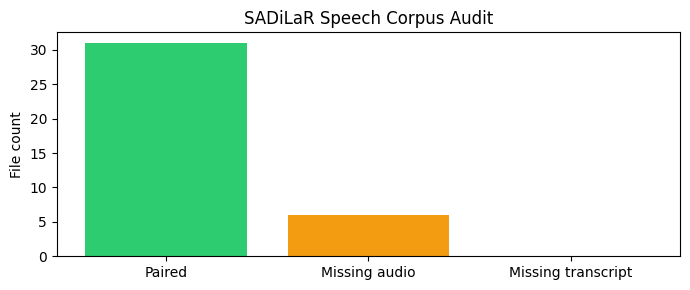

In [45]:
# SET DATA LOCATIONS


# Root folder for the SADiLaR dataset
sadilar_root = Path("data/raw/SADiLaR")

# Folder containing transcription files (.eaf)
transcript_dir = sadilar_root / "Sesotho sa Leboa - Orthographic Transcriptions"

# Folder containing audio recordings (.WAV)
recording_dir = sadilar_root / "Sesotho sa Leboa Recordings"



# LOAD FILE LISTS


# Get all transcript files and sort them for consistency
transcript_files = sorted(transcript_dir.glob("*.eaf"))

# Get all audio files and sort them
recording_files = sorted(recording_dir.glob("*.WAV"))



# NORMALISE FILE IDENTIFIERS


# Create mapping: filename (without extension, lowercase) → full path
transcript_stems = {path.stem.lower(): path for path in transcript_files}
recording_stems = {path.stem.lower(): path for path in recording_files}



# MATCH AUDIO AND TRANSCRIPTS


# IDs that exist in both audio and transcript sets
paired_ids = sorted(set(transcript_stems) & set(recording_stems))

# Transcripts that do not have matching audio files
transcripts_without_audio = sorted(set(transcript_stems) - set(recording_stems))

# Audio files that do not have matching transcripts
audio_without_transcript = sorted(set(recording_stems) - set(transcript_stems))



# BUILD MANIFEST TABLE


manifest_rows = []

# Add fully paired samples (both transcript and audio exist)
for sample_id in paired_ids:
    transcript_path = transcript_stems[sample_id]
    audio_path = recording_stems[sample_id]

    manifest_rows.append({
        "sample_id": transcript_path.stem,
        "transcript_path": str(transcript_path),
        "audio_path": str(audio_path),
        "has_transcript": True,
        "has_audio": True,
    })

# Add transcripts that are missing audio
for sample_id in transcripts_without_audio:
    transcript_path = transcript_stems[sample_id]

    manifest_rows.append({
        "sample_id": transcript_path.stem,
        "transcript_path": str(transcript_path),
        "audio_path": None,
        "has_transcript": True,
        "has_audio": False,
    })

# Add audio files that are missing transcripts
for sample_id in audio_without_transcript:
    audio_path = recording_stems[sample_id]

    manifest_rows.append({
        "sample_id": audio_path.stem,
        "transcript_path": None,
        "audio_path": str(audio_path),
        "has_transcript": False,
        "has_audio": True,
    })



# CREATE DATAFRAME + SAVE


# Convert collected rows into a structured table
df_sadilar_manifest = pd.DataFrame(manifest_rows)

# Sort for easier inspection and reset indexing
df_sadilar_manifest = df_sadilar_manifest.sort_values(["sample_id"]).reset_index(drop=True)

# Save manifest for downstream processing
df_sadilar_manifest.to_csv("outputs/alignment/sadilar_manifest.csv", index=False)



# PRINT DATASET SUMMARY


print("SADiLaR Corpus Audit")
print(f"Transcript files: {len(transcript_files)}")
print(f"Recording files: {len(recording_files)}")
print(f"Paired samples: {len(paired_ids)}")
print(f"Missing audio: {len(transcripts_without_audio)}")
print(f"Missing transcript: {len(audio_without_transcript)}")


# Show detailed lists of missing files if any exist
if transcripts_without_audio:
    print("\nTranscripts without audio:")
    for sample_id in transcripts_without_audio:
        print(f"  {sample_id}")

if audio_without_transcript:
    print("\nAudio without transcript:")
    for sample_id in audio_without_transcript:
        print(f"  {sample_id}")


# Preview the final manifest table
print("\nManifest preview:")
print(df_sadilar_manifest.head().to_string(index=False))



# VISUAL SUMMARY (AUDIT PLOT)


# Plot distribution of matched vs missing files
fig, ax = plt.subplots(figsize=(7, 3))

ax.bar(
    ["Paired", "Missing audio", "Missing transcript"],
    [len(paired_ids), len(transcripts_without_audio), len(audio_without_transcript)],
    color=["#2ecc71", "#f39c12", "#e74c3c"]
)

ax.set_ylabel("File count")
ax.set_title("SADiLaR Speech Corpus Audit")

plt.tight_layout()

# Save figure for reports or thesis figures section
plt.savefig("outputs/alignment/sadilar_audit.png", dpi=150)

plt.show()

---
## Section 8 · Subgroup Fairness Evaluation

In [46]:
def subgroup_metrics(y_true, y_prob, groups, threshold=0.5):
    # Convert probabilities into binary predictions using the threshold
    y_pred = (y_prob >= threshold).astype(int)

    results = []

    # Loop through each unique subgroup label
    for g in np.unique(groups):
        mask = groups == g  # Select samples belonging to the subgroup

        # Skip very small subgroups (less than 5 samples)
        if mask.sum() < 5:
            continue

        # Compute AUROC only if both classes exist in the subgroup
        if len(np.unique(y_true[mask])) > 1:
            auc = roc_auc_score(y_true[mask], y_prob[mask])
        else:
            auc = np.nan

        # Store performance metrics for this subgroup
        results.append({
            "subgroup": str(g),
            "n": int(mask.sum()),
            "accuracy": round(accuracy_score(y_true[mask], y_pred[mask]), 3),
            "precision": round(precision_score(y_true[mask], y_pred[mask], zero_division=0), 3),
            "recall": round(recall_score(y_true[mask], y_pred[mask], zero_division=0), 3),
            "f1": round(f1_score(y_true[mask], y_pred[mask], zero_division=0), 3),
            "auroc": round(float(auc), 3) if not np.isnan(auc) else "n/a"
        })

    # Convert list of dictionaries into a DataFrame for easy analysis
    return pd.DataFrame(results)



# SEX-BASED SUBGROUP ANALYSIS


# Map numeric sex labels into readable categories
sex_labels = pd.Series(df_test_ref["sex"].values).map({0: "Female", 1: "Male"}).values

# Compute metrics for each sex subgroup
df_fair_sex = subgroup_metrics(
    y_test,
    prob_fuse,
    sex_labels,
    CALIBRATED_THRESHOLD
)

# Add column to indicate the type of subgrouping
df_fair_sex["dimension"] = "sex"


# AGE-BASED SUBGROUP ANALYSIS


# Convert continuous age into categorical age groups
age_labels = pd.cut(
    df_test_ref["age_years"].values,
    bins=[0, 2.0, 2.5, 3.1],
    labels=["18-24m", "25-30m", "31-36m"]
).astype(str)

# Compute metrics for each age subgroup
df_fair_age = subgroup_metrics(
    y_test,
    prob_fuse,
    age_labels,
    CALIBRATED_THRESHOLD
)

# Add column to indicate subgroup type
df_fair_age["dimension"] = "age_group"



# COMBINE ALL FAIRNESS RESULTS


# Merge sex and age subgroup results into one table
df_fairness = pd.concat(
    [df_fair_sex, df_fair_age],
    ignore_index=True
)

# Print results in a clean table format
print("Fairness Evaluation")
print(df_fairness.to_string(index=False))

# Save results for later analysis or reporting
df_fairness.to_csv(
    "outputs/fairness/subgroup_results.csv",
    index=False
)

Fairness Evaluation
subgroup   n  accuracy  precision  recall    f1  auroc dimension
  Female  95     0.537      0.466   0.872 0.607  0.705       sex
    Male 157     0.643      0.649   0.906 0.757  0.730       sex
  18-24m 252     0.603      0.585   0.896 0.708  0.710 age_group


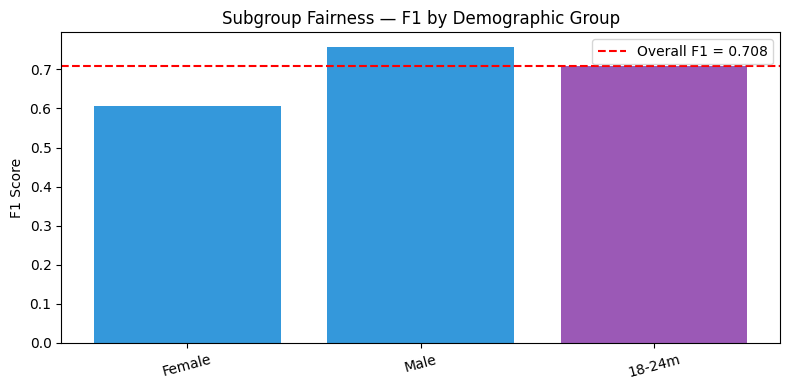

In [47]:
fig, ax = plt.subplots(figsize=(8, 4))
dim_cols = {"sex":"#3498db","age_group":"#9b59b6"}
ax.bar(df_fairness["subgroup"], df_fairness["f1"],
       color=[dim_cols[d] for d in df_fairness["dimension"]])
overall_f1 = f1_score(y_test, (prob_fuse >= CALIBRATED_THRESHOLD).astype(int), zero_division=0)
ax.axhline(overall_f1, color="red", linestyle="--", label=f"Overall F1 = {overall_f1:.3f}")
ax.set_ylabel("F1 Score")
ax.set_title("Subgroup Fairness — F1 by Demographic Group")
ax.legend()
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig("outputs/fairness/fairness_f1.png", dpi=150)
plt.show()

---
## Section 9 · Save Models

In [48]:
joblib.dump(xgb_beh,              "models/xgb_behavioural.joblib")
joblib.dump(xgb_dem,              "models/xgb_demographic.joblib")
joblib.dump(CALIBRATED_THRESHOLD, "models/threshold.joblib")

print("Models saved:")
for f in ["models/xgb_behavioural.joblib",
          "models/xgb_demographic.joblib",
          "models/threshold.joblib"]:
    print(f"  {f}  ({os.path.getsize(f):,} bytes)")

Models saved:
  models/xgb_behavioural.joblib  (311,262 bytes)
  models/xgb_demographic.joblib  (110,460 bytes)
  models/threshold.joblib  (21 bytes)
